In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Realistic Mock Data for 1000 Customers
np.random.seed(42)
num_orders = 5000
customer_ids = [f"CUST-{i:04d}" for i in np.random.randint(1, 201, num_orders)] # 200 unique customers
start_date = dt.datetime(2025, 1, 1)
end_date = dt.datetime(2025, 12, 31)

# Random dates logic
date_range = (end_date - start_date).days
order_dates = [start_date + dt.timedelta(days=int(np.random.randint(0, date_range))) for _ in range(num_orders)]
amounts = np.random.uniform(10, 500, num_orders).round(2)

df = pd.DataFrame({
    'OrderID': range(10001, 10001 + num_orders),
    'CustomerID': customer_ids,
    'OrderDate': order_dates,
    'Amount': amounts
})

print("--- Dataset Snapshot ---")
print(df.head())

--- Dataset Snapshot ---
   OrderID CustomerID  OrderDate  Amount
0    10001  CUST-0103 2025-03-24  413.63
1    10002  CUST-0180 2025-10-18  429.94
2    10003  CUST-0093 2025-03-10  213.40
3    10004  CUST-0015 2025-05-09   53.78
4    10005  CUST-0107 2025-07-15  224.51


In [2]:
# Hypothesize a "Snapshot Date" as the day after the last order in dataset
snapshot_date = df['OrderDate'].max() + dt.timedelta(days=1)

# Aggregate data by CustomerID
rfm = df.groupby('CustomerID').agg({
    'OrderDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'OrderID': 'count',                                   # Frequency
    'Amount': 'sum'                                       # Monetary
})

# Rename columns
rfm.rename(columns={
    'OrderDate': 'Recency',
    'OrderID': 'Frequency',
    'Amount': 'Monetary'
}, inplace=True)

print("\n--- Raw RFM Data ---")
print(rfm.head())


--- Raw RFM Data ---
            Recency  Frequency  Monetary
CustomerID                              
CUST-0001        12         26   6531.50
CUST-0002         8         25   7084.36
CUST-0003         1         26   6634.98
CUST-0004         6         29   6440.42
CUST-0005         1         28   8255.41


/tmp/ipykernel_726/2645841083.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


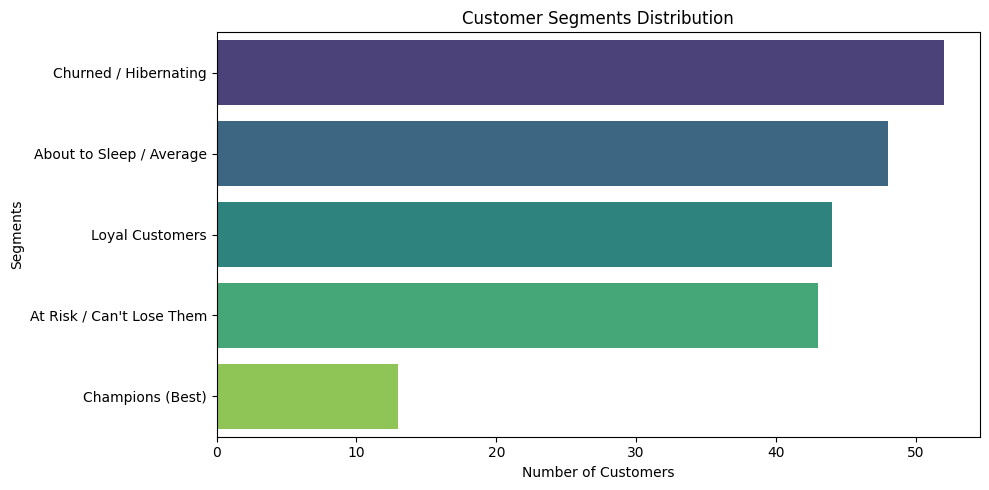

In [3]:
# Recency mein kam din achhe hote hain, isliye labels=[4, 3, 2, 1]
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])

# Frequency aur Monetary mein bada number achha hota hai
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# Combine scores to define segments
def segment_customer(df):
    if df['R_Score'] == 4 and df['F_Score'] == 4:
        return 'Champions (Best)'
    elif df['R_Score'] >= 3 and df['F_Score'] >= 3:
        return 'Loyal Customers'
    elif df['R_Score'] <= 2 and df['F_Score'] <= 2:
        return 'Churned / Hibernating'
    elif df['R_Score'] <= 2 and df['F_Score'] >= 3:
        return 'At Risk / Can\'t Lose Them'
    else:
        return 'About to Sleep / Average'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Plot the distribution of Segments
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Customer Segments Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Segments')
plt.tight_layout()
plt.show()

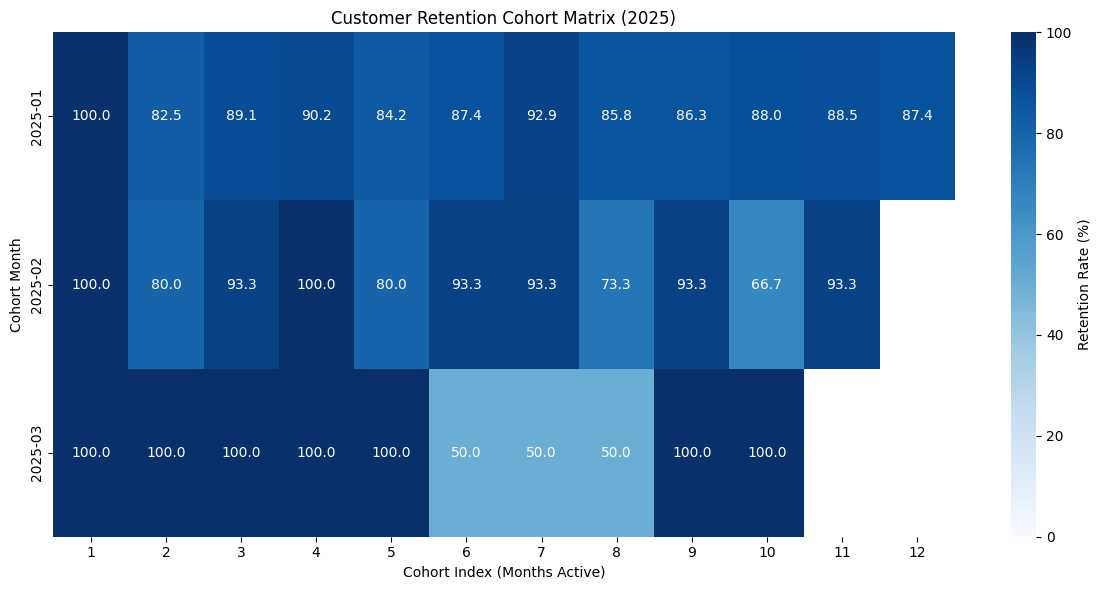

In [4]:
# 1. Extract Invoice Month and Cohort Month
df['OrderMonth'] = df['OrderDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['OrderDate'].transform('min').dt.to_period('M')

# 2. Calculate Cohort Index (Months passed since first purchase)
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

order_year, order_month = get_date_int(df, 'OrderMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

years_diff = order_year - cohort_year
months_diff = order_month - cohort_month
df['CohortIndex'] = years_diff * 12 + months_diff + 1

# 3. Count active users per cohort month and cohort index
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# 4. Calculate Retention Rate Percentage
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0).round(3) * 100

# 5. Plot the Retention Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data=retention, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Customer Retention Cohort Matrix (2025)')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index (Months Active)')
plt.tight_layout()
plt.show()

--- Correlation Matrix ---
            Recency  Frequency  Monetary
Recency    1.000000  -0.160035 -0.127495
Frequency -0.160035   1.000000  0.898068
Monetary  -0.127495   0.898068  1.000000


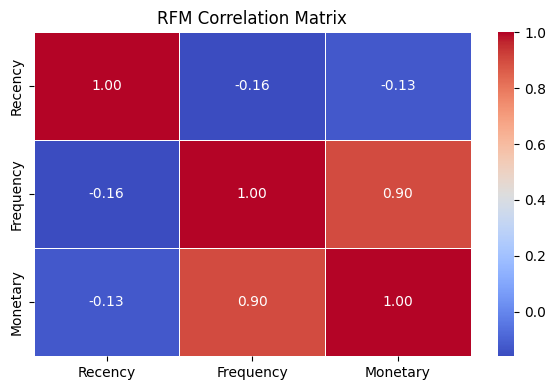

In [5]:
# Calculate correlation matrix between Recency, Frequency, and Monetary
corr_matrix = rfm[['Recency', 'Frequency', 'Monetary']].astype(float).corr()

print("--- Correlation Matrix ---")
print(corr_matrix)

# Plot Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('RFM Correlation Matrix')
plt.tight_layout()
plt.show()